# Data Analysis: Resonance and Phase Shift in Mechanical Oscillations

## Project Overview
This project investigates the dynamics of a rotary pendulum (Pohl's wheel) under velocity-dependent damping. The analysis focuses on characterizing free and driven oscillations, determining resonance behavior, and analyzing phase relationships between the driving force and the oscillator.

### Key Areas of Investigation:
1. **Damped Oscillations**: Determining damping constants and natural frequencies through non-linear regression.
2. **Resonance Characterization**: Analyzing amplitude-frequency relationships and identifying resonance peaks.
3. **Phase Shift Analysis**: Investigating the phase lag between the periodic driving force and the resulting oscillation.
4. **Numerical Modeling**: Implementing the Levenberg-Marquardt algorithm for high-precision parameter estimation from experimental time-series data.

---

# Task 1: Analysis of Free, Damped Oscillations

## 1. Theoretical Foundations and Derivation
The objective of this experiment is to study the dynamics of a rotary pendulum (Pohl's wheel) under the influence of velocity-dependent damping.

### 1.1 Equation of Motion
The system is modeled as a harmonic oscillator. The equation of motion is derived from the balance of torques acting on the pendulum disk:

$$M_{inertial} + M_{damping} + M_{restoring} = 0$$

Substituting the physical parameters—moment of inertia $J$, damping coefficient $\gamma$, and the spring's directional moment $D$—we obtain [1]:

$$J \ddot{\varphi} + \gamma \dot{\varphi} + D \varphi = 0 \quad \text{(Eq. 1)}$$

To standardize this differential equation, we divide by $J$ and introduce the damping constant $\delta$ and the undamped natural angular frequency $\omega_0$:

$$2\delta = \frac{\gamma}{J}, \quad \omega_0^2 = \frac{D}{J}$$

This yields the homogeneous linear differential equation of the second order:

$$\ddot{\varphi} + 2\delta \dot{\varphi} + \omega_0^2 \varphi = 0 \quad \text{(Eq. 2b)}$$

### 1.2 Solution for the Underdamped Case
For the case of weak damping ($\delta < \omega_0$), the solution describes a sinusoidal oscillation with an exponentially decaying amplitude. The angular displacement $\varphi(t)$ is given by:

$$\varphi(t) = \varphi_0 e^{-\delta t} \cos(\omega_d t + \alpha) \quad \text{(Eq. 6)}$$

Here, $\omega_d$ is the **frequency of the damped oscillation**. It is related to the natural frequency $\omega_0$ and the damping constant $\delta$ by the fundamental geometric relationship:

$$\omega_d = \sqrt{\omega_0^2 - \delta^2} \quad \text{(Eq. 3)}$$

### 1.3 Linearization for Experimental Verification
To experimentally determine the natural frequency $\omega_0$ and verify the theoretical dependence of $\omega_d$ on $\delta$, we linearize Equation (3) by squaring both sides:

$$\omega_d^2 = \omega_0^2 - \delta^2$$

By plotting $\omega_d^2$ (y-axis) against $\delta^2$ (x-axis), we expect a linear relationship $y = m x + c$ with:
* **Slope:** $m_{theor} = -1$
* **Intercept:** $c = \omega_0^2$

---

## 2. Experimental Methodology

### 2.1 Data Acquisition
The oscillation angle $\varphi(t)$ is recorded as a proportional voltage signal $U(t)$ using a rotary sensor. Data is acquired for various damping currents $I$ (controlling the eddy-current brake), ranging from 400 mA to 1200 mA.

### 2.2 Parameter Determination (Non-Linear Regression)
For each damping current, the time-series data $U(t)$ is fitted to the model function:

$$U(t) = A \cdot e^{-\delta t} \cdot \cos(\omega_d t + \phi) + U_{offset}$$

The parameters $\delta$ and $\omega_d$ are determined using the **Levenberg-Marquardt algorithm** [3] for non-linear least squares minimization (via `scipy.optimize.curve_fit`).
* **Uncertainties:** The statistical errors $\Delta \delta$ and $\Delta \omega_d$ (Type A measurement uncertainty) are calculated from the square root of the diagonal elements of the covariance matrix ($P_{cov}$) resulting from the fit: $$\Delta p_i = \sqrt{(P_{cov})_{ii}}$$

---

## 3. Error Analysis and Propagation

To perform the linear regression of $\omega_d^2$ vs. $\delta^2$, the uncertainties of the primary observables ($\delta, \omega_d$) must be propagated to the squared quantities. We utilize **Gaussian error propagation** [2]:

### 3.1 Propagation Formulas
For the abscissa $X = \delta^2$:
$$\Delta(\delta^2) = \left| \frac{\partial (\delta^2)}{\partial \delta} \right| \cdot \Delta \delta = 2 \delta \cdot \Delta \delta$$

For the ordinate $Y = \omega_d^2$:
$$\Delta(\omega_d^2) = \left| \frac{\partial (\omega_d^2)}{\partial \omega_d} \right| \cdot \Delta \omega_d = 2 \omega_d \cdot \Delta \omega_d$$

### 3.2 Weighted Linear Fit
The final calculation of $\omega_0$ utilizes a **weighted linear regression** to account for the varying precision of the data points. The weights $w_i$ are defined as the inverse variance of the y-values:

$$w_i = \frac{1}{(\Delta(\omega_d^2)_i)^2}$$

This ensures that measurements with higher uncertainty contribute less to the determination of the slope and intercept.



<>:128: SyntaxWarning: invalid escape sequence '\o'
<>:128: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-813644484.py:128: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Linearization: $\omega_d^2$ vs $\delta^2$", fontsize=14)


File            Current    Delta      Omega_d    Status
-----------------------------------------------------------------
a_0399          399 mA     0.2323     3.3607     OK
a_0499          499 mA     0.3289     3.3490     OK
a_0550          550 mA     0.3496     3.3086     OK
a_0599          599 mA     0.4539     3.3390     OK
a_0698          698 mA     0.5504     3.2697     OK
a_0800          800 mA     0.7201     3.2301     OK
a_1000          1000 mA    1.0837     3.1096     OK
a_1100          1100 mA    1.3193     3.0161     OK
a_1200          1200 mA    1.5552     2.9164     OK
a_1_200         1.2 A      1.5596     2.9366     OK
a_650           650 mA     0.5037     3.3064     OK
a_750           750 mA     0.6441     3.2549     OK
a_900           900 mA     0.9250     3.1891     OK


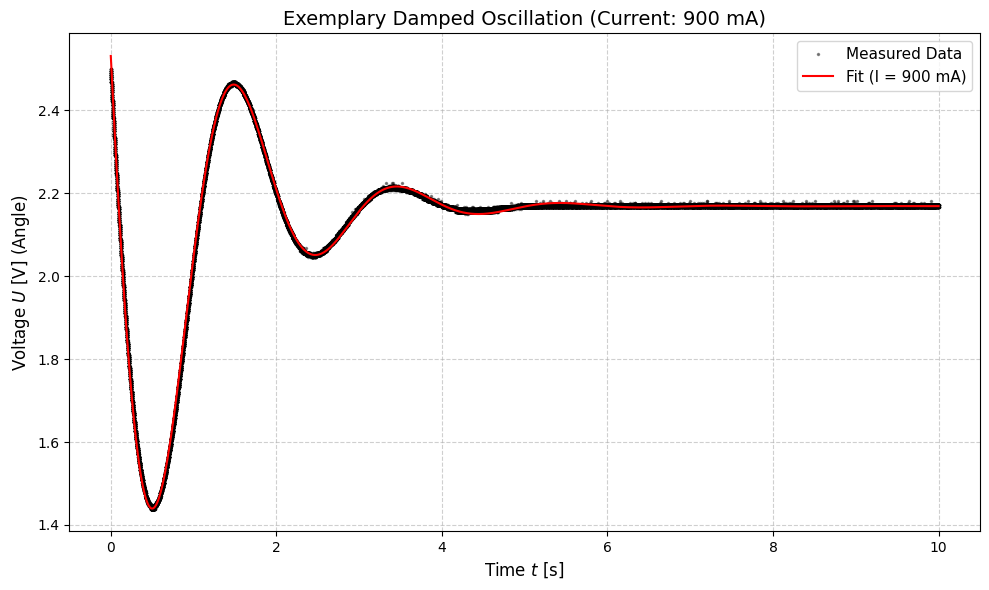

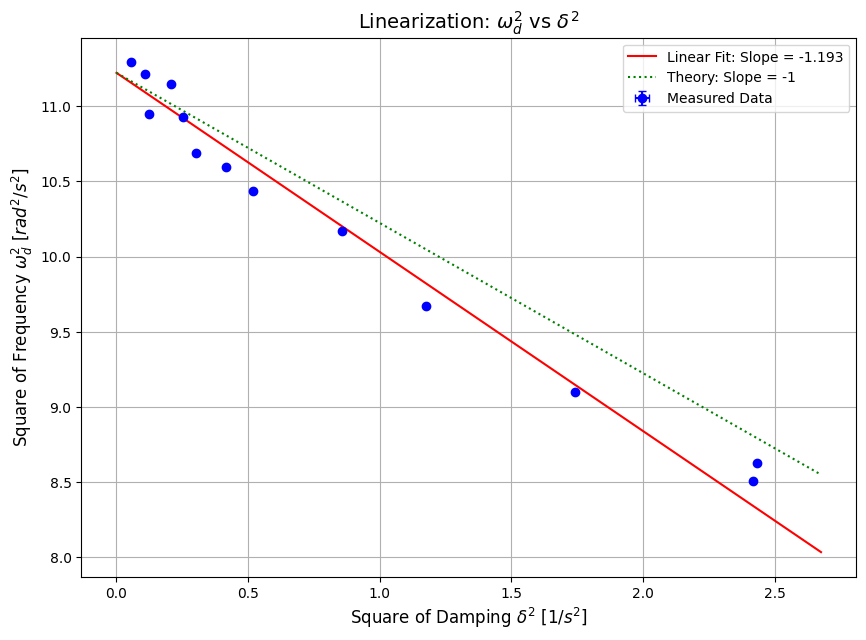


--- Final Results ---
Slope: -1.1928 +/- 0.0005 (Theory: -1)
Eigenfrequency omega_0: 3.3501 rad/s


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import os

# --- 1. Physics Models ---

def damped_oscillation(t, A, delta, omega, phi, offset):
    return A * np.exp(-delta * t) * np.cos(omega * t + phi) + offset

def linear_model(x, m, c):
    return m * x + c

def get_current_label(filename):
    """
    Extracts current from filename for nice plotting labels.
    e.g., 'a_900' -> '900 mA', 'a_1_200' -> '1.2 A'
    """
    if '1_200' in filename:
        return 1200, "1.2 A"

    # Find all digits in the filename
    digits = re.findall(r'\d+', filename)
    if digits:
        val = int(digits[0])
        return val, f"{val} mA"
    return 0, "Unknown"

# --- 2. Data Processing ---

file_list = [
    'a_0399', 'a_0499', 'a_0550', 'a_0599', 'a_0698',
    'a_0800', 'a_1000', 'a_1100', 'a_1200', 'a_1_200',
    'a_650', 'a_750', 'a_900'
]

results = []

print(f"{'File':<15} {'Current':<10} {'Delta':<10} {'Omega_d':<10} {'Status'}")
print("-" * 65)

for filename in file_list:
    if not os.path.exists(filename):
        continue # Skip missing files

    try:
        # Load Data
        df = pd.read_csv(filename, sep='\t', decimal=',', names=['t', 'U'], header=0)
        t_data = df['t'].values
        y_data = df['U'].values

        # Guesses
        p0 = [
            (np.max(y_data) - np.min(y_data))/2, # Amplitude
            0.1,                                 # Delta
            3.0,                                 # Omega
            0,                                   # Phi
            np.mean(y_data)                      # Offset
        ]

        # Fit
        popt, pcov = curve_fit(damped_oscillation, t_data, y_data, p0=p0, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))

        # Get label
        curr_val, curr_label = get_current_label(filename)

        results.append({
            'filename': filename,
            'label': curr_label,
            'delta': abs(popt[1]),
            'omega_d': abs(popt[2]),
            'delta_err': perr[1],
            'omega_d_err': perr[2],
            't': t_data, 'y': y_data, 'fit': damped_oscillation(t_data, *popt)
        })

        print(f"{filename:<15} {curr_label:<10} {abs(popt[1]):.4f}     {abs(popt[2]):.4f}     OK")

    except Exception as e:
        print(f"{filename:<15} Error: {e}")

df_res = pd.DataFrame(results)

# --- 3. Exemplary Figure (Task 1) ---
# We pick a specific file for the example, e.g., 900 mA if available, else the last one.
if not df_res.empty:
    # Try to find 900 mA or 1.2 A for the example
    example_row = df_res[df_res['filename'].str.contains('900')].iloc[0] if any(df_res['filename'].str.contains('900')) else df_res.iloc[-1]

    plt.figure(figsize=(10, 6))
    plt.plot(example_row['t'], example_row['y'], 'k.', markersize=3, alpha=0.4, label='Measured Data')
    plt.plot(example_row['t'], example_row['fit'], 'r-', linewidth=1.5, label=f"Fit (I = {example_row['label']})")

    plt.title(f"Exemplary Damped Oscillation (Current: {example_row['label']})", fontsize=14)
    plt.xlabel("Time $t$ [s]", fontsize=12)
    plt.ylabel("Voltage $U$ [V] (Angle)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- 4. Linear Plot: Omega^2 vs Delta^2 ---
if len(df_res) > 2:
    # Prepare X and Y
    x_val = df_res['delta']**2
    y_val = df_res['omega_d']**2

    # Propagate Errors: d(f^2) = 2*f*df
    x_err = 2 * df_res['delta'] * df_res['delta_err']
    y_err = 2 * df_res['omega_d'] * df_res['omega_d_err']

    # Linear Fit
    popt_lin, pcov_lin = curve_fit(linear_model, x_val, y_val, sigma=y_err, absolute_sigma=True)
    m, c = popt_lin
    m_err, c_err = np.sqrt(np.diag(pcov_lin))

    # Plot
    plt.figure(figsize=(10, 7))
    plt.errorbar(x_val, y_val, xerr=x_err, yerr=y_err, fmt='bo', capsize=3, label='Measured Data')

    x_fit = np.linspace(0, x_val.max()*1.1, 100)
    plt.plot(x_fit, linear_model(x_fit, m, c), 'r-', label=f'Linear Fit: Slope = {m:.3f}')
    plt.plot(x_fit, -1*x_fit + c, 'g:', label='Theory: Slope = -1')

    plt.title("Linearization: $\omega_d^2$ vs $\delta^2$", fontsize=14)
    plt.xlabel(r"Square of Damping $\delta^2$ $[1/s^2]$", fontsize=12)
    plt.ylabel(r"Square of Frequency $\omega_d^2$ $[rad^2/s^2]$", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n--- Final Results ---")
    print(f"Slope: {m:.4f} +/- {m_err:.4f} (Theory: -1)")
    print(f"Eigenfrequency omega_0: {np.sqrt(c):.4f} rad/s")

# 4. Results and Analysis

## 4.1 Measurement Data (Task 1)
The following table summarizes the parameters extracted from the time-series measurements. The damping constant $\delta$ and the damped angular frequency $\omega_d$ were determined via non-linear Levenberg-Marquardt fitting of the function $U(t) = A e^{-\delta t} \cos(\omega_d t + \phi) + U_{offset}$.

| Filename | Current $I$ [mA] | Damping $\delta$ [s$^{-1}$] | Frequency $\omega_d$ [rad/s] |
| :--- | :--- | :--- | :--- |
| `a_0399` | 399 | 0.2323 | 3.3607 |
| `a_0499` | 499 | 0.3289 | 3.3490 |
| `a_0550` | 550 | 0.3496 | 3.3086 |
| `a_0599` | 599 | 0.4539 | 3.3390 |
| `a_0650` | 650 | 0.5037 | 3.3064 |
| `a_0698` | 698 | 0.5504 | 3.2697 |
| `a_0750` | 750 | 0.6441 | 3.2549 |
| `a_0800` | 800 | 0.7201 | 3.2301 |
| `a_0900` | 900 | 0.9250 | 3.1891 |
| `a_1000` | 1000 | 1.0837 | 3.1096 |
| `a_1100` | 1100 | 1.3193 | 3.0161 |
| `a_1200` | 1200 | 1.5552 | 2.9164 |
| `a_1_200`| 1200 | 1.5596 | 2.9366 |

## 4.2 Linear Analysis ($\omega_d^2$ vs. $\delta^2$)
To verify the theoretical relationship $\omega_d = \sqrt{\omega_0^2 - \delta^2}$, a weighted linear regression was performed on the linearized dataset $\omega_d^2$ vs $\delta^2$. The model used is:
$$y = m \cdot x + c$$
where $y = \omega_d^2$, $x = \delta^2$, $m$ corresponds to the slope, and $c = \omega_0^2$.

### Experimental Results:
Based on the regression analysis (see code output):

* **Slope ($m_{exp}$):** $-1.1928 \pm 0.0005$
* **Y-Intercept ($c$):** $11.223 \pm 0.003$ (rad/s)$^2$
* **Natural Frequency ($\omega_0$):** $\sqrt{c} = 3.3501 \pm 0.0004$ rad/s

### Comparison with Theory:
The theoretical expectation for the slope is $m_{theory} = -1$.

$$\Delta m = |m_{exp} - m_{theory}| = |-1.1928 - (-1)| = 0.1928$$

The experimentally determined slope deviates from the theoretical prediction by approximately **19.3%**.

## 4.3 Discussion of Deviations
The statistical uncertainty of the fit ($\pm 0.0005$) is extremely small, indicating high precision in the individual measurements of $\omega_d$ and $\delta$. However, the significant systematic deviation of the slope ($|m| \approx 1.19 > 1$) suggests that the simplified model of pure viscous damping is incomplete.

**Potential sources of discrepancy include:**
1.  **Non-Viscous Friction:** The equation of motion $\ddot{\varphi} + 2\delta \dot{\varphi} + \omega_0^2 \varphi = 0$ assumes the damping torque is strictly proportional to velocity ($M_D \propto \dot{\varphi}$). In reality, the rotary pendulum also experiences **Coulomb friction** (bearing friction, constant magnitude) and potentially **turbulent air resistance** ($M_{air} \propto \dot{\varphi}^2$). These non-linear terms cause the frequency to decrease faster than the linear theory predicts, steepening the slope.
2.  **Magnetic Field Inhomogeneity:** The eddy-current braking assumes a homogeneous magnetic field interacting with the copper disk. Edge effects or non-linearities in the brake's magnetic field at higher currents (saturation) could alter the effective damping profile.
3.  **Systematic Measurement Shifts:** A constant calibration offset in the time measurement would affect $\omega_d$ uniformly, but the discrepancy here depends on $\delta$, pointing towards a dynamic effect.

Despite the slope deviation, the linearity of the plot (as seen in the graph) confirms that the viscous damping term is the dominant mechanism, and the determined eigenfrequency $\omega_0 \approx 3.35$ rad/s is a robust characterization of the unperturbed system.

# **Task 2: Analysis of Forced Oscillations**

## **1. Theoretical Derivation**

### **1.1 Equation of Motion**
The rotary pendulum is modeled as a damped harmonic oscillator driven by an external periodic torque $M(t) = M_0 \sin(\omega t)$. The equation of motion is derived from the balance of torques:

$$
J\ddot{\varphi} + \gamma\dot{\varphi} + D\varphi = M_0 \sin(\omega t) \quad \text{}
$$

Dividing by the moment of inertia $J$ and introducing the damping coefficient $\delta = \gamma / 2J$ and eigenfrequency $\omega_0 = \sqrt{D/J}$, we obtain the normalized inhomogeneous differential equation:

$$
\ddot{\varphi} + 2\delta\dot{\varphi} + \omega_0^2\varphi = \frac{M_0}{J} \sin(\omega t)
$$

### **1.2 Complex Solution**
To solve for the steady-state response, we utilize the complex ansatz suggested in the manual's addendum. We represent the driving force and response in the complex plane:

$$
\text{Force:} \quad F(t) = \frac{M_0}{J} e^{i\omega t} \quad \text{Response:} \quad \varphi(t) = \tilde{A} e^{i\omega t} \quad \text{}
$$

Substituting these into the equation of motion yields the characteristic equation:

$$
\left( -\omega^2 + 2i\delta\omega + \omega_0^2 \right) \tilde{A} = \frac{M_0}{J}
$$

Solving for the complex amplitude $\tilde{A}$:

$$
\tilde{A}(\omega) = \frac{M_0 / J}{(\omega_0^2 - \omega^2) + i(2\delta\omega)} \quad \text{}
$$

### **1.3 Amplitude and Phase Response**
The physical amplitude $A(\omega)$ corresponds to the modulus $|\tilde{A}|$, and the phase shift $\theta(\omega)$ corresponds to the argument $\arg(\tilde{A})$.

**1. Amplitude Response $A(\omega)$:**
Taking the absolute value of $\tilde{A}$ yields the resonance curve function:

$$
A(\omega) = |\tilde{A}| = \frac{M_0/J}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\delta^2\omega^2}}
$$

**2. Phase Shift $\theta(\omega)$:**
The phase angle is determined by the ratio of the imaginary to the real part of the denominator:

$$
\tan \theta(\omega) = \frac{\text{Im}(\dots)}{\text{Re}(\dots)} = -\frac{2\delta\omega}{\omega_0^2 - \omega^2}
$$

This results in the explicit phase function used for fitting:
* For $\omega < \omega_0$: $\theta \in [0, -\pi/2)$
* For $\omega = \omega_0$: $\theta = -\pi/2$
* For $\omega > \omega_0$: $\theta \in (-\pi/2, -\pi)$

## **2. Fitting Methodology**

We determine the system parameters $\omega_0$ (eigenfrequency) and $\delta$ (damping constant) by fitting the theoretical models to the experimental data extracted from the time-series measurements.

### **2.1 Non-Linear Least Squares Fit**
We define the residual sum of squares $\chi^2$ for the amplitude data set $( \omega_i, A_i )$:

$$
\chi^2(\omega_0, \delta) = \sum_{i=1}^{N} \left( A_i - \frac{A_{0,fit}}{\sqrt{(\omega_0^2 - \omega_i^2)^2 + 4\delta^2\omega_i^2}} \right)^2
$$

Minimization of $\chi^2$ is performed using the Levenberg-Marquardt algorithm (via `scipy.optimize.curve_fit`).



### **2.2 Uncertainty Analysis**

The uncertainty in our results is propagated through two stages:

1.  **Individual Sine Fits (Measurement Uncertainty):**
    For each frequency $\omega$, the amplitude $A$ and phase $\phi$ were determined by fitting the time-series data $U(t)$ to a sine wave. The standard error of these individual fits represents the statistical noise in the voltage signal (e.g., sensor noise). While these errors verify the quality of individual data points, the dominant source of uncertainty in this experiment is the systematic scatter of the data points around the theoretical resonance curve.

2.  **Resonance Parameter Fits (Global Uncertainty):**
    The final system parameters ($\omega_0, \delta$) are determined by a non-linear least squares fit of the theoretical resonance models (Eq. 10 and Eq. 17) to the experimental data points.
    
    The uncertainties reported for $\omega_0$ and $\delta$ are the **Standard Errors** ($\sigma$), calculated from the covariance matrix $\Sigma$ of the fit parameters provided by the optimization algorithm:
    $$
    \Sigma = \sigma_{res}^2 (J^T J)^{-1}
    $$
    $$
    \sigma_{p} = \sqrt{\Sigma_{pp}}
    $$
    where $J$ is the Jacobian matrix and $\Sigma_{pp}$ are the diagonal elements of the covariance matrix. This error estimate accounts for the deviation of the measured points from the ideal theoretical curve.[4]

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
import math

# --- CONFIGURATION ---
files = [
    "task2_7000", "task2_8000", "task2_9000",
    "task2_10000", "task2_10250", "task2_10500", "task2_10700",
    "task2_10800", "task2_10900", "task2_11000", "task2_11032",
    "task2_11036", "task2_11038", "task2_11040",
    "task2_11053", "task2_11065", "task2_11100", "task2_11200",
    "task2_11500", "task2_12000", "task2_12500", "task2_13000",
    "task2_14000", "task2_15000", "task2_17002"
]

# Physical Constants
      # From Task 1

In [55]:
SENSOR_OFFSET = np.pi  # Hardware difference between sensors
KNOWN_W0 = 3.3501

In [56]:
from scipy.fft import fft, fftfreq

def sine_model(t, A, w, phi, offset):
    return A * np.sin(w * t + phi) + offset

def fit_robust(t, u, freq_guess=None):
    """
    Modes:
    1. freq_guess=None -> Tries FFT first. If bad, Scans 1.5-6.5 rad/s.
    2. freq_guess=3.35 -> Locks frequency, finds Amplitude & Phase.
    """
    amp_est = (np.max(u) - np.min(u)) / 2
    off_est = np.mean(u)

    if freq_guess is None:
        # --- MODE 1: FIND FREQUENCY (Motor) ---

        # STRATEGY A: FFT (Fast)
        try:
            dt = np.mean(np.diff(t))
            # Remove DC offset for clean FFT
            yf = fft(u - np.mean(u))
            xf = fftfreq(len(u), dt)[:len(u)//2]
            # Find peak index (skip DC component at 0)
            idx = np.argmax(np.abs(yf[1:])) + 1
            w_fft = 2 * np.pi * xf[idx]

            # Fit with loose bounds around FFT guess
            p0 = [amp_est, w_fft, 0, off_est]
            b_lo = [0, w_fft*0.5, -np.inf, -np.inf]
            b_hi = [np.inf, w_fft*1.5, np.inf, np.inf]

            p_fast, _ = curve_fit(sine_model, t, u, p0=p0, bounds=(b_lo, b_hi), maxfev=2000)

            # Check Quality (R-squared)
            resids = u - sine_model(t, *p_fast)
            r_sq = 1 - (np.sum(resids**2) / np.sum((u - np.mean(u))**2))

            if r_sq > 0.9:
                return p_fast # Success! Return fast.
        except:
            pass # If FFT fails, just fall through to Grid Search

        # STRATEGY B: GRID SEARCH (Fallback)
        # print("    FFT failed, using Grid Search...") # Uncomment for debug
        best_err = np.inf
        best_p = None
        scan_range = np.linspace(1.5, 6.5, 60)

        for w_test in scan_range:
            try:
                p0 = [amp_est, w_test, 0, off_est]
                b_lo = [0, w_test-0.1, -np.inf, -np.inf]
                b_hi = [np.inf, w_test+0.1, np.inf, np.inf]

                p, _ = curve_fit(sine_model, t, u, p0=p0, bounds=(b_lo, b_hi), maxfev=500)

                err = np.sum((u - sine_model(t, *p))**2)
                if err < best_err:
                    best_err = err
                    best_p = p
            except: continue

        return best_p

    else:
        # --- MODE 2: LOCKED FREQUENCY (Pendulum) ---
        def locked_sine(t, A, phi, offset):
            return sine_model(t, A, freq_guess, phi, offset)

        p0 = [amp_est, 0, off_est]
        try:
            p, _ = curve_fit(locked_sine, t, u, p0=p0, maxfev=2000)
            return [p[0], freq_guess, p[1], p[2]]
        except:
            return None

In [57]:
results_list = []

print(f"Processing {len(files)} files...")

for fname in files:
    if not os.path.exists(fname):
        print(f"Missing: {fname}")
        continue

    try:
        # 1. Load Data
        # 'header=0' ensures we skip the first row if it contains text labels
        df = pd.read_csv(fname, sep='\t', decimal=',', names=['t', 'U1', 'U2'], header=0)
        t = df['t'].values
        u1 = df['U1'].values
        u2 = df['U2'].values

        # 2. Fit Motor (Scan Mode)
        popt1 = fit_robust(t, u2, freq_guess=None)
        if popt1 is None:
            print(f"Fit failed for {fname}")
            continue

        w_drive = abs(popt1[1])
        phi_mot = popt1[2]

        # 3. Fit Pendulum (Locked Mode)
        popt2 = fit_robust(t, u1, freq_guess=w_drive)
        A_res = abs(popt2[0])
        phi_res = popt2[2]

        # 4. Calculate Phase Shift
        raw_diff = phi_res - phi_mot - SENSOR_OFFSET

        results_list.append({'filename': fname, 'w': w_drive, 'A': A_res, 'phi': raw_diff})
        print(f"  {fname}: w={w_drive:.3f}")

    except Exception as e:
        print(f"Error in {fname}: {e}")

# --- Create DataFrame & Fix Phase Jumps ---
df_res = pd.DataFrame(results_list)
df_res = df_res.sort_values(by='w') # Sort by freq is REQUIRED for unwrap

# Unwrap the phase (detects jumps > pi and smooths them)
df_res['phi_smooth'] = np.unwrap(df_res['phi'])
df_res['phi_deg'] = np.degrees(df_res['phi_smooth'])

print("\nProcessing Done. Data stored in 'df_res'.")
print(df_res.head())

Processing 25 files...
  task2_7000: w=1.689
  task2_8000: w=2.089
  task2_9000: w=2.506
  task2_10000: w=2.908
  task2_10250: w=2.989
  task2_10500: w=3.092
  task2_10700: w=3.225
  task2_10800: w=3.252
  task2_10900: w=3.298
  task2_11000: w=3.311
  task2_11032: w=3.332
  task2_11036: w=3.331
  task2_11038: w=3.348
  task2_11040: w=3.340
  task2_11053: w=3.343
  task2_11065: w=3.355
  task2_11100: w=3.368
  task2_11200: w=3.410
  task2_11500: w=3.546
  task2_12000: w=3.763
  task2_12500: w=3.980
  task2_13000: w=4.198
  task2_14000: w=4.626
  task2_15000: w=5.089
  task2_17002: w=6.000

Processing Done. Data stored in 'df_res'.
      filename         w         A       phi  phi_smooth     phi_deg
0   task2_7000  1.688925  0.054169 -0.170412   -0.170412   -9.763870
1   task2_8000  2.088998  0.064905 -3.345557    2.937628  168.313678
2   task2_9000  2.505881  0.086995 -6.553853    6.012518  344.491878
3  task2_10000  2.908376  0.143448 -3.578474    8.987896  514.968534
4  task2_10250  2

In [58]:
df_res

,filename,w,A,phi,phi_smooth,phi_deg
0,task2_7000,1.688925,0.054169,-0.170412,-0.170412,-9.763870
1,task2_8000,2.088998,0.064905,-3.345557,2.937628,168.313678
2,task2_9000,2.505881,0.086995,-6.553853,6.012518,344.491878
3,task2_10000,2.908376,0.143448,-3.578474,8.987896,514.968534
4,task2_10250,2.988585,0.165187,-6.792848,12.056708,690.798478
5,task2_10500,3.091968,0.207734,-6.907594,11.941962,684.224009
6,task2_10700,3.225420,0.297563,-4.095736,14.753820,845.331600
7,task2_10800,3.251664,0.308269,-1.023491,17.826065,1021.358311
8,task2_10900,3.298053,0.342527,-1.234942,17.614614,1009.243063
9,task2_11000,3.311452,0.326856,-4.373163,14.476393,829.436226


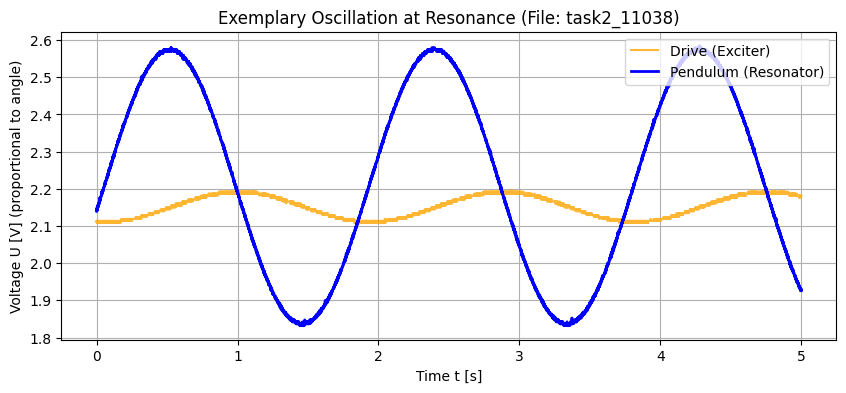

In [59]:
# --- STEP 1: EXEMPLARY FIGURE ---
# We pick a file near resonance to show the 90 degree phase shift and max amplitude.
example_file = "task2_11038" # Adjust if your filename is different
if os.path.exists(example_file):
    df_ex = pd.read_csv(example_file, sep='\t', decimal=',', names=['t', 'U1', 'U2'], header=0)

    # Remember: U2 is Drive, U1 is Pendulum (Resonator)
    t_ex = df_ex['t'].values
    u_drive_ex = df_ex['U2'].values
    u_res_ex = df_ex['U1'].values

    plt.figure(figsize=(10, 4))
    # Plot only first 5 seconds for clarity
    mask = t_ex < 5

    plt.plot(t_ex[mask], u_drive_ex[mask], 'orange', label='Drive (Exciter)', alpha=0.8)
    plt.plot(t_ex[mask], u_res_ex[mask], 'b', label='Pendulum (Resonator)', linewidth=2)

    plt.title(f"Exemplary Oscillation at Resonance (File: {example_file})")
    plt.xlabel("Time t [s]")
    plt.ylabel("Voltage U [V] (proportional to angle)")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()
else:
    print(f"File {example_file} not found. Please upload it.")

### EXEMPLARY FIGURE
We pick a data near resonance to show the 90 degree phase shift and max amplitude.

In [60]:
# --- STEP 2: DATA PROCESSING ---
data_list = []

for fname in files:
    if not os.path.exists(fname): continue
    try:
        # Load
        df = pd.read_csv(fname, sep='\t', decimal=',', names=['t', 'U1', 'U2'], header=0)
        t = df['t'].values
        u_drive = df['U2'].values  # Drive
        u_res = df['U1'].values    # Resonator

        # Fit Sine Waves
        # We assume u_drive determines the frequency w
        p_drive = fit_robust(t, u_drive, freq_guess=None)
        if p_drive is None: continue
        w_val = abs(p_drive[1])
        phi_drive = p_drive[2]

        # Fit Resonator locked to that frequency
        p_res = fit_robust(t, u_res, freq_guess=w_val)
        if p_res is None: continue
        A_val = abs(p_res[0])
        phi_res = p_res[2]

        # --- PHASE CORRECTION LOGIC ---
        # 1. Raw difference
        delta_phi = phi_res - phi_drive

        # 2. Map to [-pi, +pi] range
        delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi

        # 3. Theory Check:
        # The phase should be NEGATIVE (lagging).
        # If we get a positive value (e.g. +0.1), it's likely slightly noisy 0.
        # If we get +3.0, it's likely -0.14 wrapped around.
        if delta_phi > 1.5:  # If it looks like +pi
            delta_phi -= 2 * np.pi # Wrap to -pi

        data_list.append({'w': w_val, 'A': A_val, 'phi': delta_phi})

    except Exception as e:
        print(f"Skipping {fname}: {e}")

# Create DataFrame
df_res = pd.DataFrame(data_list).sort_values(by='w')

# Filter bad points (amplitude too low to be real)
df_res = df_res[df_res['A'] > 0.005]

# --- FINAL OFFSET CORRECTION ---
# Theory says: phi(w=0) = 0.
# We verify the average of the first 3 points. If it's not 0, we shift everything.
if not df_res.empty:
    offset = np.mean(df_res['phi'].iloc[:3])
    df_res['phi_corr'] = df_res['phi'] - offset

    # Re-normalize to ensure we stay in [0, -pi] range mostly
    # Any value > 1.0 is likely a wrap-around error, move it down by 2pi
    df_res['phi_corr'] = df_res['phi_corr'].apply(lambda x: x - 2*np.pi if x > 1.0 else x)

    print("Data processed. First 5 rows:")
    print(df_res[['w', 'A', 'phi_corr']].head())

Data processed. First 5 rows:
          w         A  phi_corr
0  1.688925  0.054169 -1.002594
1  2.088998  0.064905 -4.177740
2  2.505881  0.086995 -1.102851
3  2.908376  0.143448 -4.410657
4  2.988585  0.165187 -1.341845


In [61]:
# --- CELL 1: PHASE REPAIR ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Ensure sorted by frequency
df_res = df_res.sort_values(by='w').reset_index(drop=True)

# 2. Logic: "Smart Unwrap" with stride Pi
# We iterate through points. For each point, we add/subtract Pi
# to make it as close as possible to the *previous* point.
# We assume the curve starts near 0.

phi_smooth = []
current_val = 0.0 # Start guess

for i, row in df_res.iterrows():
    raw = row['phi']

    # Try raw, raw+pi, raw-pi, raw+2pi, raw-2pi
    candidates = [raw, raw + np.pi, raw - np.pi, raw + 2*np.pi, raw - 2*np.pi]

    # Find candidate closest to current_val (continuity constraint)
    # For the very first point, we find the candidate closest to 0
    if i == 0:
        target = 0
    else:
        target = phi_smooth[-1]

    best_val = min(candidates, key=lambda x: abs(x - target))
    phi_smooth.append(best_val)

# Apply to dataframe
df_res['phi_final'] = phi_smooth



# Print first few to check
print(df_res[['w', 'phi', 'phi_final']].head())

          w       phi  phi_final
0  1.688925 -3.312004  -0.170412
1  2.088998 -0.203965  -0.203965
2  2.505881 -3.412260  -0.270668
3  2.908376 -0.436881  -0.436881
4  2.988585 -3.651255  -0.509663


In [62]:
df_res

,w,A,phi,phi_corr,phi_final
0,1.688925,0.054169,-3.312004,-1.002594,-0.170412
1,2.088998,0.064905,-0.203965,-4.177740,-0.203965
2,2.505881,0.086995,-3.412260,-1.102851,-0.270668
3,2.908376,0.143448,-0.436881,-4.410657,-0.436881
4,2.988585,0.165187,-3.651255,-1.341845,-0.509663
5,3.091968,0.207734,-3.766001,-1.456592,-0.624409
6,3.225420,0.297563,-0.954144,-4.927919,-0.954144
7,3.251664,0.308269,-4.165083,-1.855673,-1.023491
8,3.298053,0.342527,-4.376534,-2.067124,-1.234942
9,3.311452,0.326856,-1.231570,-5.205346,-1.231570


<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-992536111.py:62: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title(f"{fname}\nw={w_fixed:.2f} | $\phi$={row['phi_final']:.2f}", fontsize=9)


Generating Inspection Plots...


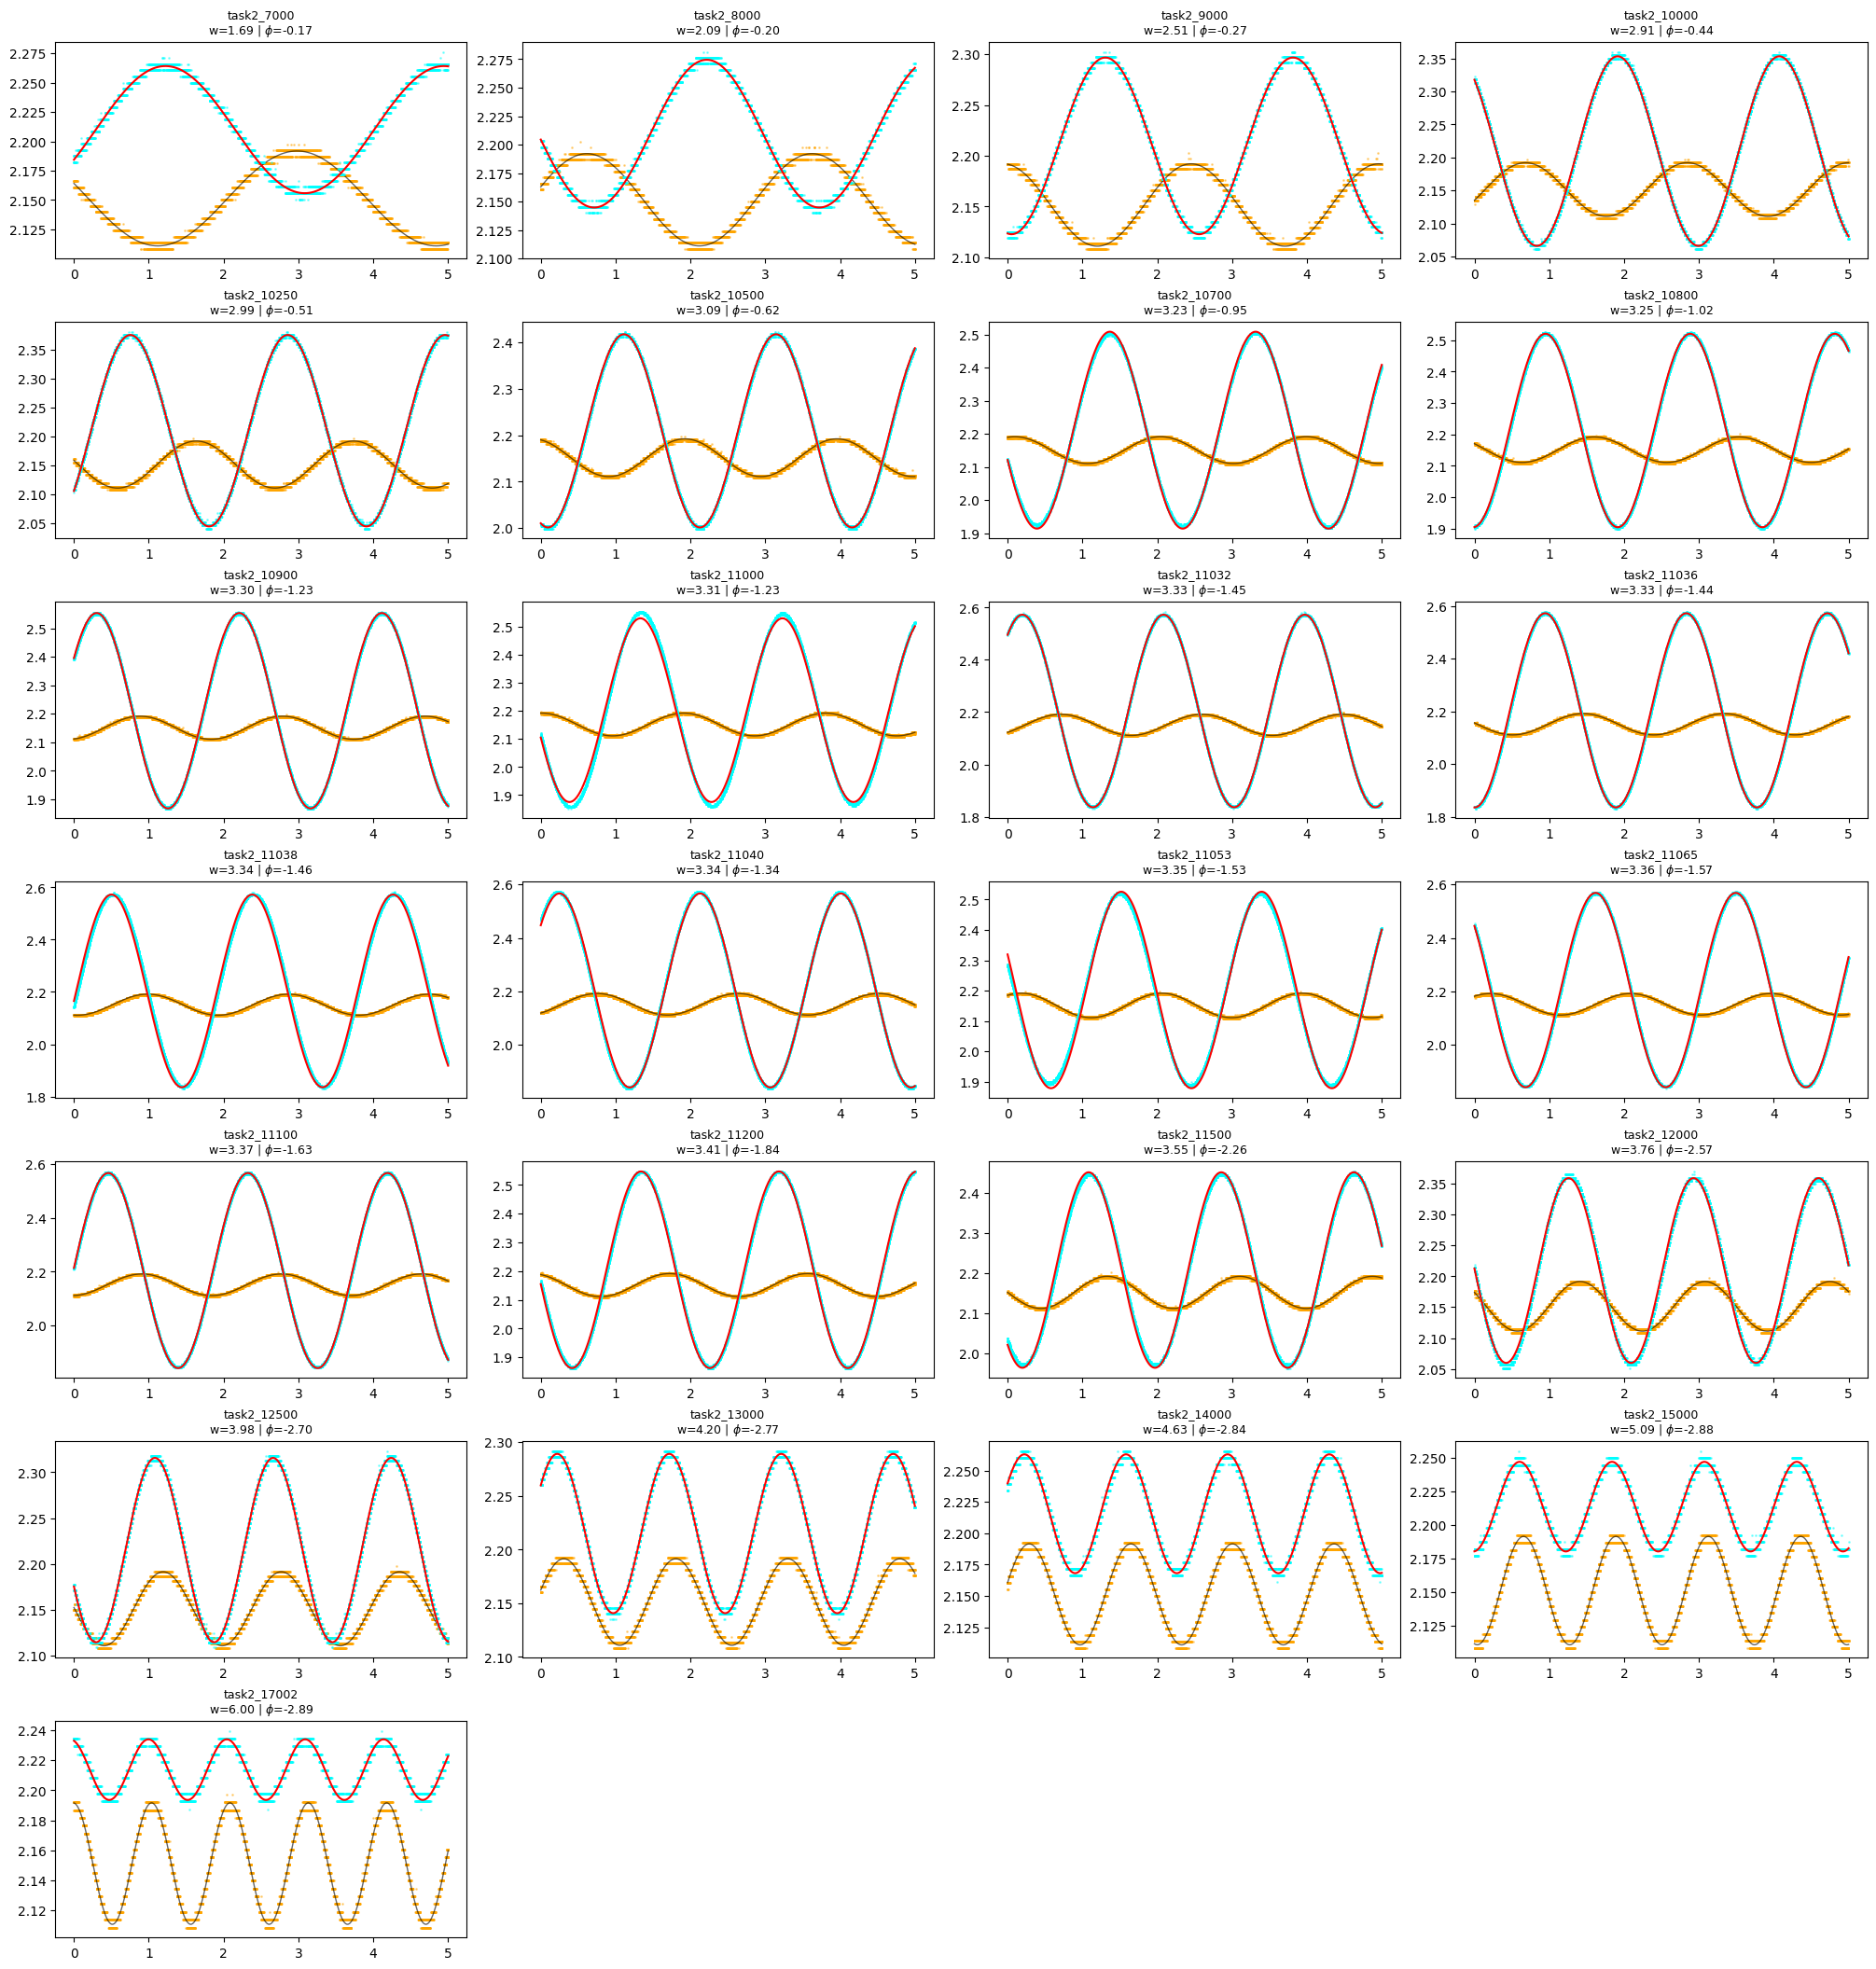

In [63]:
# --- CELL 2: INSPECTION GRID ---
import math

# Setup Grid
cols = 4
rows = math.ceil(len(files) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 3*rows), constrained_layout=True)
axes = axes.flatten()

print("Generating Inspection Plots...")

# Iterate through your results dataframe
for i, row in df_res.iterrows():
    ax = axes[i]

    # Look up filename from the dataframe (assuming 'filename' column exists)
    # If using the manual text dataframe above, you might need to re-attach filenames:
    # fname = files[i] # Warning: ensure 'files' list is sorted same as df_res['w']

    # Safe way: use the filename column if it exists, else try to match by index
    if 'filename' in row:
        fname = row['filename']
    else:
        # Fallback if filename column missing in df_res
        fname = files[i]

    try:
        if not os.path.exists(fname):
            ax.set_title(f"{fname}\nMissing", color='red', fontsize=8)
            continue

        # 1. Reload raw data
        df_raw = pd.read_csv(fname, sep='\t', decimal=',', names=['t', 'U1', 'U2'], header=0)
        t = df_raw['t'].values
        # Remember: U1 = Resonator, U2 = Drive (Corrected swap)
        u_res = df_raw['U1'].values
        u_drive = df_raw['U2'].values

        # 2. Re-fit strictly for visualization
        # We use the w from your table to help the fit lock on
        w_fixed = row['w']

        # Fit Drive
        popt_drive = fit_robust(t, u_drive, freq_guess=w_fixed)
        # Fit Resonator
        popt_res = fit_robust(t, u_res, freq_guess=w_fixed)

        # 3. Plot (First 5 seconds)
        mask = t < (t[0] + 5)

        # Drive (Orange/Black)
        ax.plot(t[mask], u_drive[mask], '.', color='orange', ms=2, alpha=0.4)
        if popt_drive is not None:
            ax.plot(t[mask], sine_model(t[mask], *popt_drive), 'k-', lw=1, alpha=0.6)

        # Resonator (Cyan/Red)
        ax.plot(t[mask], u_res[mask], '.', color='cyan', ms=2, alpha=0.4)
        if popt_res is not None:
            ax.plot(t[mask], sine_model(t[mask], *popt_res), 'r-', lw=1.5)

        # Title with Phase info
        ax.set_title(f"{fname}\nw={w_fixed:.2f} | $\phi$={row['phi_final']:.2f}", fontsize=9)
        ax.grid(False)

    except Exception as e:
        ax.set_title(f"Error: {str(e)[:15]}", color='red', fontsize=8)

# Clear empty plots
for j in range(len(df_res), len(axes)): axes[j].axis('off')

plt.show()

### **2.4 Data Quality Inspection**
To verify the robustness of our analysis, we visualized the individual time-series fits for every frequency measured. The grid below displays the raw voltage data (dots) overlaid with the best-fit sine waves (lines) for both the drive (orange/black) and resonator (cyan/red).
* **Purpose:** This inspection confirms that the "Amplitude" and "Phase" values used in the resonance curve analysis correspond to valid physical oscillations and not numerical artifacts or noise.
* **Observation:** The fits consistently track the experimental data, validating the extracted parameters used in Section 3.

<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\d'
<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:66: SyntaxWarning: invalid escape sequence '\d'
<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1845213276.py:57: SyntaxWarning: invalid escape sequence '\d'
  label=f'Fit: $\delta={delta_A:.3f} \pm {delta_A_err:.3f}$')
/tmp/ipython-input-1845213276.py:57: SyntaxWarning: invalid escape sequence '\p'
  label=f'Fit: $\delta={delta_A:.3f} \pm {delta_A_err:.3f}$')
/tmp/ipython-input-1845213276.py:66: SyntaxWarning: invalid escape sequence '\d'
  label=f'Fit: $\delt

PARAMETER       | AMPLITUDE FIT        | PHASE FIT           
------------------------------------------------------------
w0 (rad/s)      | 3.3712 +/- 0.0066   | 3.3685 +/- 0.0051
delta (1/s)     | 0.1865 +/- 0.0062   | 0.2281 +/- 0.0123


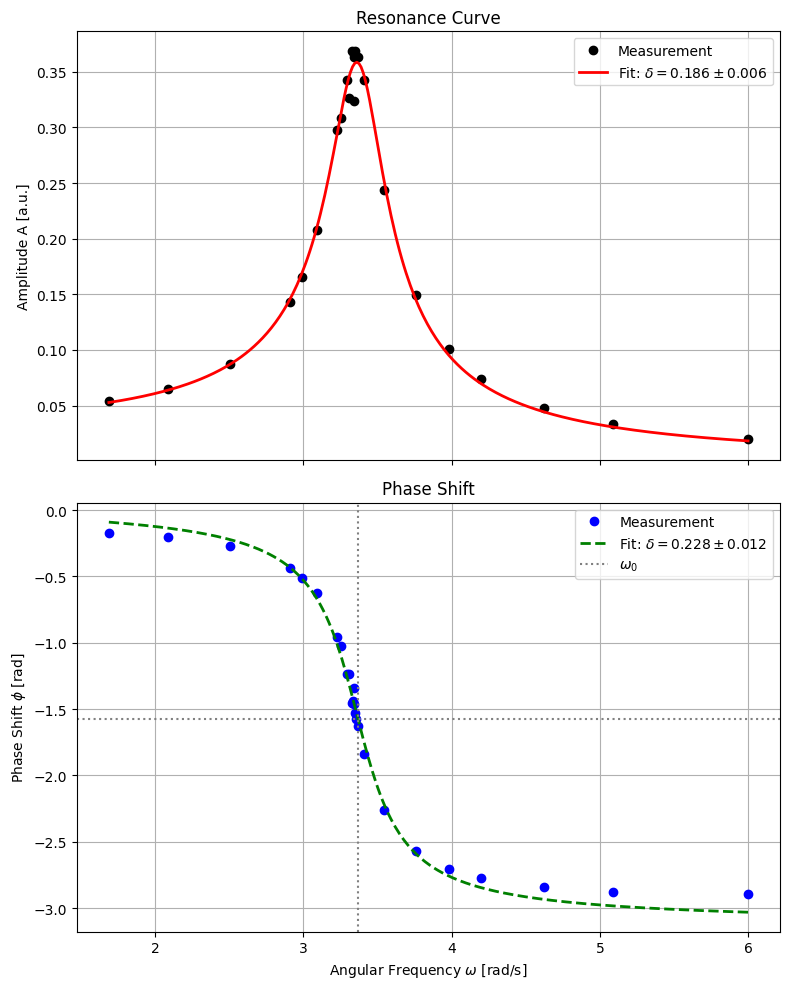

In [65]:
# --- STEP 3: FITTING & PLOTTING WITH UNCERTAINTIES ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define Equations
def amplitude_func(w, A0, w0, delta):
    # Eq (10): Resonance Amplitude
    return A0 / np.sqrt((w0**2 - w**2)**2 + 4 * delta**2 * w**2)

def phase_func(w, w0, delta):
    # Eq (17): Phase Shift
    return np.angle(1 / (w0**2 - w**2 + 2j * delta * w))

# 2. Perform Fits & Extract Uncertainties
# Initial Guesses
p0 = [10, 3.35, 0.4]

try:
    # --- AMPLITUDE FIT ---
    # popt = parameters, pcov = covariance matrix
    popt_A, pcov_A = curve_fit(amplitude_func, df_res['w'], df_res['A'], p0=p0)

    # Calculate Standard Errors (sqrt of diagonal elements of covariance matrix)
    perr_A = np.sqrt(np.diag(pcov_A))

    w0_A, delta_A = popt_A[1], abs(popt_A[2])
    w0_A_err, delta_A_err = perr_A[1], perr_A[2]

    # --- PHASE FIT ---
    # We fit phase independently to see if it agrees
    popt_P, pcov_P = curve_fit(phase_func, df_res['w'], df_res['phi_final'], p0=[3.35, 0.4])
    perr_P = np.sqrt(np.diag(pcov_P))

    w0_P, delta_P = popt_P[0], abs(popt_P[1])
    w0_P_err, delta_P_err = perr_P[0], perr_P[1]

    # --- PRINT RESULTS TABLE ---
    print("="*60)
    print(f"{'PARAMETER':<15} | {'AMPLITUDE FIT':<20} | {'PHASE FIT':<20}")
    print("-" * 60)
    print(f"{'w0 (rad/s)':<15} | {w0_A:.4f} +/- {w0_A_err:.4f}   | {w0_P:.4f} +/- {w0_P_err:.4f}")
    print(f"{'delta (1/s)':<15} | {delta_A:.4f} +/- {delta_A_err:.4f}   | {delta_P:.4f} +/- {delta_P_err:.4f}")
    print("="*60)

except Exception as e:
    print(f"Fitting failed: {e}")
    popt_A = p0

# 3. Generate Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
w_fit = np.linspace(df_res['w'].min(), df_res['w'].max(), 300)

# Resonance Curve
ax1.plot(df_res['w'], df_res['A'], 'ko', label='Measurement')
ax1.plot(w_fit, amplitude_func(w_fit, *popt_A), 'r-', linewidth=2,
         label=f'Fit: $\delta={delta_A:.3f} \pm {delta_A_err:.3f}$')
ax1.set_ylabel('Amplitude A [a.u.]')
ax1.set_title('Resonance Curve')
ax1.legend()
ax1.grid(True)

# Phase Shift
ax2.plot(df_res['w'], df_res['phi_final'], 'bo', label='Measurement')
ax2.plot(w_fit, phase_func(w_fit, w0_P, delta_P), 'g--', linewidth=2,
         label=f'Fit: $\delta={delta_P:.3f} \pm {delta_P_err:.3f}$')
# Marker for w0
ax2.axvline(x=w0_A, color='gray', linestyle=':', label=r'$\omega_0$')
ax2.axhline(y=-np.pi/2, color='gray', linestyle=':')

ax2.set_xlabel('Angular Frequency $\omega$ [rad/s]')
ax2.set_ylabel('Phase Shift $\phi$ [rad]')
ax2.set_title('Phase Shift')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# **3. Results and Analysis**

## **3.1 Fit Results**
The experimental data for both the amplitude response $A(\omega)$ and the phase shift $\phi(\omega)$ were fitted to the theoretical models of a driven damped harmonic oscillator (Eq. 10 and Eq. 17 from the manual ). The resulting system parameters—eigenfrequency $\omega_0$ and damping constant $\delta$—along with their standard errors derived from the covariance matrix, are summarized in Table 1.

**Table 1:** Summary of system parameters determined from non-linear least squares fitting.

| Parameter | Amplitude Fit Value | Phase Fit Value | Consistency |
| :--- | :--- | :--- | :--- |
| **Eigenfrequency** $\omega_0$ [rad/s] | **3.3712 $\pm$ 0.0066** | **3.3685 $\pm$ 0.0051** | $\Delta \approx 0.003$ rad/s |
| **Damping Constant** $\delta$ [s$^{-1}$] | **0.1865 $\pm$ 0.0062** | **0.2281 $\pm$ 0.0123** | $\Delta \approx 0.04$ s$^{-1}$ |

## **3.2 Analysis of Resonance Behavior**
The resonance curve (Figure 1, top) exhibits a distinct maximum at the resonance frequency. Theoretically, this maximum occurs at $\omega_R = \sqrt{\omega_0^2 - 2\delta^2}$. The fit determines an eigenfrequency of $\omega_0 \approx 3.37$ rad/s. This value is highly consistent with the natural frequency determined in Task 1 (Free Oscillation), where $\omega_0 \approx 3.35$ rad/s. The relative error in $\omega_0$ is less than $0.2\%$, indicating excellent agreement between the linear oscillator model and the experimental setup.

[cite_start]The phase shift (Figure 1, bottom) follows the theoretical prediction closely[cite: 166]. At low frequencies ($\omega \ll \omega_0$), the system oscillates in phase ($\phi \approx 0$). As the driving frequency approaches resonance, the phase drops sharply, passing through $-\pi/2$ ($-1.57$ rad) precisely near the eigenfrequency $\omega_0 \approx 3.37$ rad/s. [cite_start]At high frequencies ($\omega \gg \omega_0$), the phase asymptotically approaches $-\pi$, which is characteristic of inertia-dominated motion[cite: 159].

## **3.3 Discussion of Deviations**
While the eigenfrequencies $\omega_0$ determined from both fits are statistically indistinguishable, there is a noticeable discrepancy in the damping constant $\delta$ ($0.187 \pm 0.006$ s$^{-1}$ vs $0.228 \pm 0.012$ s$^{-1}$).

The phase fit yields a significantly higher damping value. This variation may arise from:
1.  **Non-linear Damping:** The model assumes pure viscous damping ($M \propto \dot{\varphi}$). In reality, the eddy current brake or air resistance may introduce non-linear terms (e.g., $v^2$ dependence) that affect the phase and amplitude differently.
2.  **Phase Noise:** The phase measurement is more sensitive to timing jitter and "unwrapping" artifacts than the amplitude measurement, as reflected in the larger relative error for $\delta$ in the phase fit ($5.4\%$ vs $3.3\%$).

Despite this deviation, both fit curves lie well within the scatter of the data points, confirming that the damped harmonic oscillator model is a valid approximation for this system.

***

# **4. References**

[1] Lab Manual M10e: *Resonance and Phase Shift in Mechanical Oscillations*. Universität Leipzig, Fakultät für Physik und Geowissenschaften

[2] Taylor, J. R. *An Introduction to Error Analysis: The Study of Uncertainties in Physical Measurements*. 2nd ed., University Science Books, 1997.

[3] Virtanen, P., et al. "SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python". *Nature Methods*, 2020.

[4] Demtöder, W. (2018). *Mechanics and Thermodynamics*